# KELT-20b TESS exploration

This notebook is for exploratory TESS photometry work on KELT-20b:
- fetch SPOC 2-minute light curves
- stitch and flatten the sectors
- inspect the phase-folded transit
- inspect sector-level / epoch-level behavior
- optionally build and sample a PyMC + exoplanet transit model

It is not part of the retrieval pipeline itself. The retrieval currently uses derived scalar photometric constraints, not raw TESS light curves.



In [1]:
import warnings

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning, module="pytensor")

TARGET = "KELT-20"
MISSION = "TESS"
AUTHOR = "SPOC"
EXPTIME_S = 120

PERIOD_D = 3.4741039
T0_BTJD = 1698.210775
TRANSIT_DURATION_D = 3.54 / 24.0
PLOT_WINDOW_D = 0.15

search = lk.search_lightcurve(TARGET, mission=MISSION, author=AUTHOR, exptime=EXPTIME_S)
display(search)

lc_collection = search.download_all()
print(f"Downloaded {len(lc_collection)} light curves")



/opt/homebrew/Caskroom/miniconda/base/envs/kelt20-tess/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 14,2019,SPOC,120,69679391,0.0
1,TESS Sector 40,2021,SPOC,120,69679391,0.0
2,TESS Sector 41,2021,SPOC,120,69679391,0.0
3,TESS Sector 54,2022,SPOC,120,69679391,0.0
4,TESS Sector 74,2024,SPOC,120,69679391,0.0
5,TESS Sector 75,2024,SPOC,120,69679391,0.0
6,TESS Sector 81,2024,SPOC,120,69679391,0.0


Downloaded 7 light curves


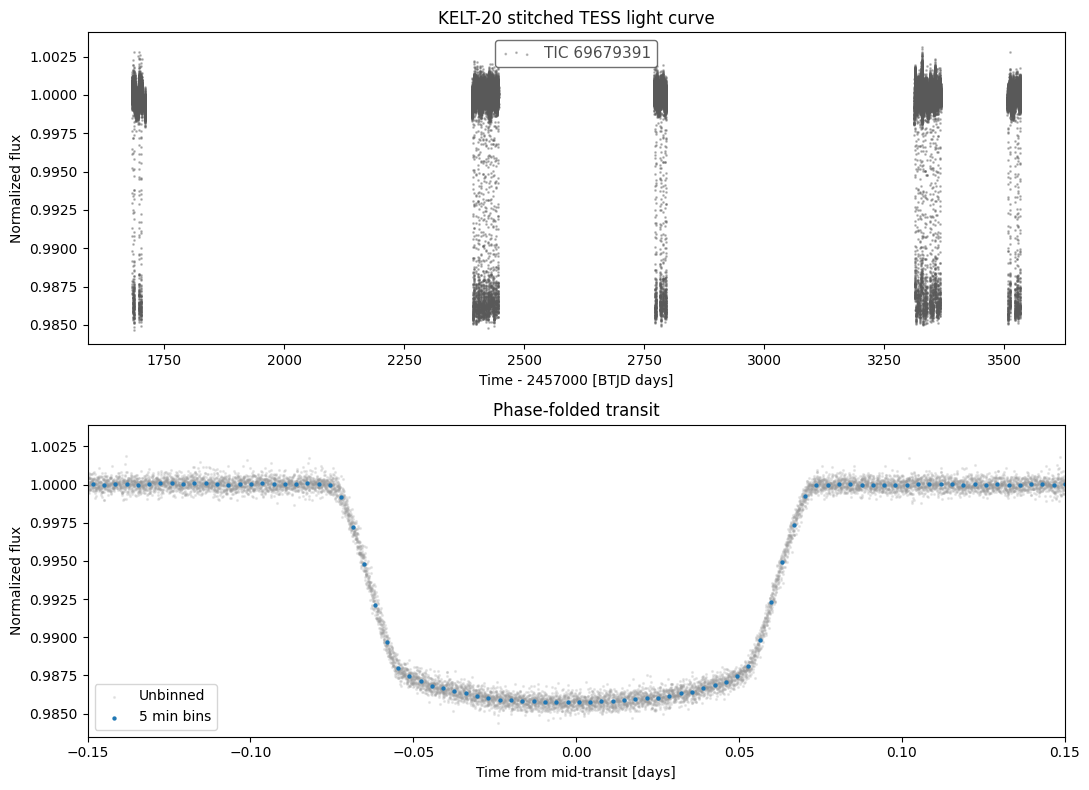

In [2]:
stitched_lc = lc_collection.stitch().remove_nans().normalize()
transit_mask = stitched_lc.create_transit_mask(
    period=PERIOD_D,
    transit_time=T0_BTJD,
    duration=TRANSIT_DURATION_D,
)
flat_lc = stitched_lc.flatten(window_length=901, mask=transit_mask)
folded_lc = flat_lc.fold(period=PERIOD_D, epoch_time=T0_BTJD)
binned_folded_lc = folded_lc.bin(time_bin_size=5.0 / (24.0 * 60.0))

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

stitched_lc.scatter(ax=axes[0], color="0.35", alpha=0.35, s=4)
axes[0].set_title("KELT-20 stitched TESS light curve")
axes[0].set_ylabel("Normalized flux")

folded_lc.scatter(ax=axes[1], color="0.6", alpha=0.18, s=6, label="Unbinned")
binned_folded_lc.scatter(ax=axes[1], color="tab:blue", s=18, label="5 min bins")
axes[1].set_xlim(-PLOT_WINDOW_D, PLOT_WINDOW_D)
axes[1].set_title("Phase-folded transit")
axes[1].set_xlabel("Time from mid-transit [days]")
axes[1].set_ylabel("Normalized flux")
axes[1].legend()

plt.tight_layout()



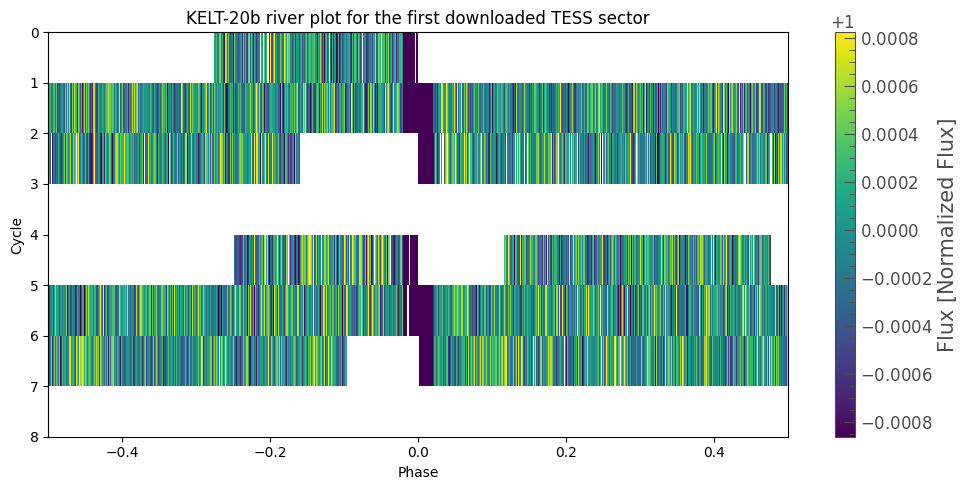

In [3]:
sector_lc = lc_collection[0].remove_nans().normalize()
sector_transit_mask = sector_lc.create_transit_mask(
    period=PERIOD_D,
    transit_time=T0_BTJD,
    duration=TRANSIT_DURATION_D,
)
sector_flat_lc = sector_lc.flatten(window_length=901, mask=sector_transit_mask)
sector_folded_lc = sector_flat_lc.fold(period=PERIOD_D, epoch_time=T0_BTJD)

fig, ax = plt.subplots(figsize=(10, 5))
sector_folded_lc.plot_river(ax=ax)
ax.set_aspect("auto")
ax.set_title("KELT-20b river plot for the first downloaded TESS sector")
plt.tight_layout()



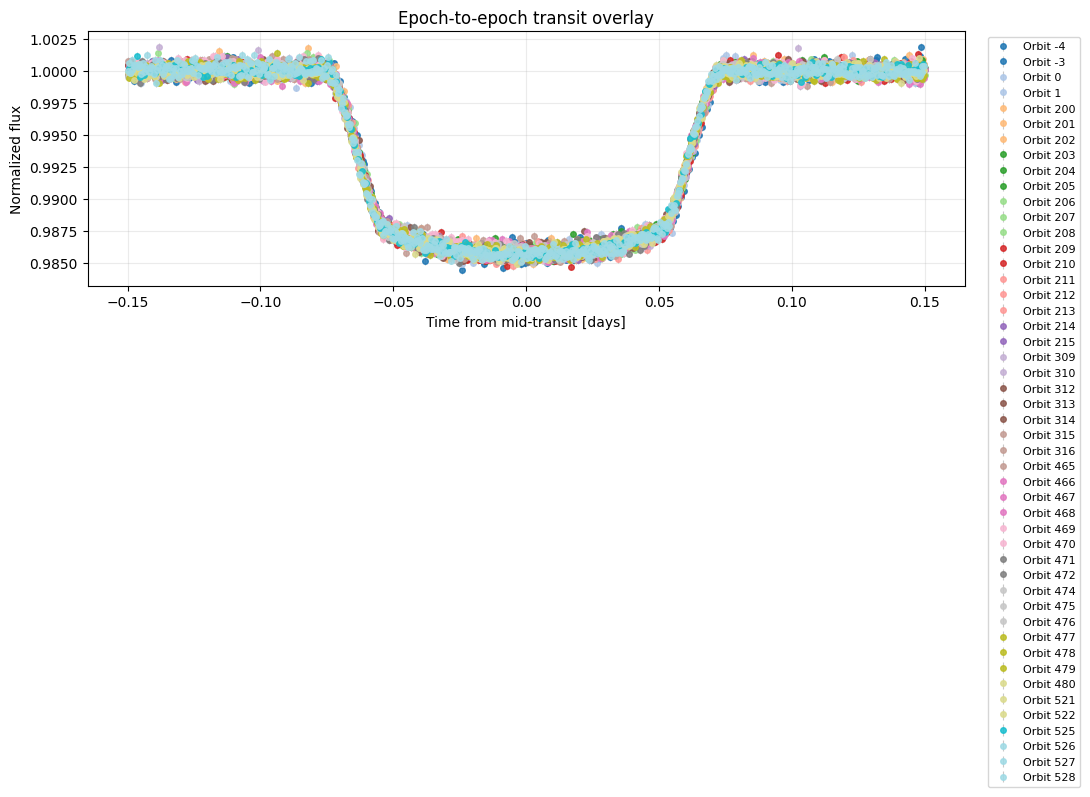

In [4]:
time_btjd = flat_lc.time.value
phase_days = ((time_btjd - T0_BTJD + 0.5 * PERIOD_D) % PERIOD_D) - 0.5 * PERIOD_D
epoch_number = np.round((time_btjd - T0_BTJD) / PERIOD_D).astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
unique_epochs = np.unique(epoch_number)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_epochs)))

for color, current_epoch in zip(colors, unique_epochs):
    mask = (epoch_number == current_epoch) & (np.abs(phase_days) < PLOT_WINDOW_D)
    if not np.any(mask):
        continue
    ax.errorbar(
        phase_days[mask],
        flat_lc.flux.value[mask],
        yerr=flat_lc.flux_err.value[mask],
        fmt="o",
        ms=4,
        color=color,
        ecolor="0.75",
        elinewidth=0.8,
        capsize=0,
        alpha=0.85,
        label=f"Orbit {current_epoch}",
    )

ax.set_title("Epoch-to-epoch transit overlay")
ax.set_xlabel("Time from mid-transit [days]")
ax.set_ylabel("Normalized flux")
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()



## Optional PyMC / exoplanet transit model

Run the next cells only if the PyMC transit-model stack imports successfully in this notebook environment.



In [5]:
try:
    import pymc as pm
    import pytensor.tensor as pt
    import exoplanet as xo
    from celerite2.pymc import GaussianProcess, terms
except Exception as exc:
    print(
        "Optional modeling dependencies could not be imported. "
        "This is usually either a missing package (for example celerite2) "
        "or an incompatible exoplanet-core / JAX combination."
    )
    print(f"Import failure: {type(exc).__name__}: {exc}")
else:
    clean_lc = lc_collection[0].remove_nans().normalize().remove_outliers(sigma=5.0)
    x = np.ascontiguousarray(clean_lc.time.value, dtype=np.float64)
    y = np.ascontiguousarray(clean_lc.flux.value - 1.0, dtype=np.float64)
    yerr = np.ascontiguousarray(clean_lc.flux_err.value, dtype=np.float64)

    guess_depth = 8.0e-4
    guess_r = np.sqrt(guess_depth)

    with pm.Model() as model:
        mean_flux = pm.Normal("mean_flux", mu=0.0, sigma=0.01)
        period = pm.Normal("period", mu=PERIOD_D, sigma=0.01)
        t0 = pm.Normal("t0", mu=T0_BTJD, sigma=0.01)
        r = pm.Uniform("r", lower=0.01, upper=0.5, initval=guess_r)
        b = pm.Uniform("b", lower=0.0, upper=1.0, initval=0.5)
        u = xo.distributions.QuadLimbDark("u")

        orbit = xo.orbits.KeplerianOrbit(period=period, t0=t0, b=b)
        light_curves = xo.LimbDarkLightCurve(u).get_light_curve(
            orbit=orbit,
            r=r,
            t=x,
            use_in_transit=False,
        )
        transit_model = pm.Deterministic("transit_model", pt.sum(light_curves, axis=-1))

        log_sigma = pm.Normal("log_sigma", mu=np.log(np.std(y)), sigma=5.0)
        log_rho = pm.Normal("log_rho", mu=np.log(1.0), sigma=5.0)
        kernel = terms.SHOTerm(
            sigma=pt.exp(log_sigma),
            rho=pt.exp(log_rho),
            Q=1.0 / np.sqrt(2.0),
        )

        gp = GaussianProcess(
            kernel,
            t=x,
            diag=yerr**2,
            mean=transit_model + mean_flux,
        )

        gp.marginal("obs", observed=y)
        pm.Deterministic("gp_pred", gp.predict(y))

    print("Model graph built successfully. Continue with the next cells for MAP, sampling, and plots.")



Model graph built successfully. Continue with the next cells for MAP, sampling, and plots.


/opt/homebrew/Caskroom/miniconda/base/envs/kelt20-tess/lib/python3.10/site-packages/celerite2/pymc/ops.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## MAP optimization and posterior sampling

Run these only after the model cell above succeeds.



In [ ]:
with model:
    map_soln = pm.find_MAP()

print({k: map_soln[k] for k in ["mean_flux", "period", "t0", "r", "b"]})

with model:
    idata = pm.sample(
        tune=1000,
        draws=1000,
        chains=2,
        cores=2,
        target_accept=0.9,
        init="adapt_diag",
    )



Output()

{'mean_flux': array(-5.73461741e-05), 'period': array(3.4741039), 't0': array(1698.210775), 'r': array(0.02828427), 'b': array(0.5)}


Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mean_flux, period, t0, r, b, __u_q1, __u_q2, log_sigma, log_rho]


Output()

In [ ]:
import arviz as az

az.summary(idata, var_names=["mean_flux", "period", "t0", "r", "b", "log_sigma", "log_rho"])



In [ ]:
az.plot_trace(idata, var_names=["mean_flux", "period", "t0", "r", "b", "log_sigma", "log_rho"])
plt.tight_layout()



In [ ]:
posterior = idata.posterior

mean_flux_med = posterior["mean_flux"].median(dim=("chain", "draw")).item()
period_med = posterior["period"].median(dim=("chain", "draw")).item()
t0_med = posterior["t0"].median(dim=("chain", "draw")).item()
r_med = posterior["r"].median(dim=("chain", "draw")).item()
b_med = posterior["b"].median(dim=("chain", "draw")).item()
u_med = posterior["u"].median(dim=("chain", "draw")).values
gp_pred_med = posterior["gp_pred"].median(dim=("chain", "draw")).values

orbit_med = xo.orbits.KeplerianOrbit(period=period_med, t0=t0_med, b=b_med)
light_curve_med = xo.LimbDarkLightCurve(u_med).get_light_curve(
    orbit=orbit_med,
    r=r_med,
    t=x,
    use_in_transit=False,
).eval()
transit_model_med = np.sum(light_curve_med, axis=-1)
model_flux_med = gp_pred_med + mean_flux_med
detrended_flux = y - gp_pred_med - mean_flux_med

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

axes[0].plot(x, y, ".", color="0.4", alpha=0.25, ms=4, label="Data")
axes[0].plot(x, model_flux_med, color="tab:orange", lw=2, label="GP mean")
axes[0].plot(x, transit_model_med + mean_flux_med, color="tab:green", lw=2, label="Transit + mean")
axes[0].set_title("Raw light curve with fitted model components")
axes[0].set_xlabel("Time [BTJD]")
axes[0].set_ylabel("Flux - 1")
axes[0].legend()

axes[1].plot(x, detrended_flux, ".", color="0.35", alpha=0.25, ms=4, label="Detrended data")
axes[1].plot(x, transit_model_med, color="tab:red", lw=2, label="Transit model")
axes[1].set_title("GP-detrended light curve")
axes[1].set_xlabel("Time [BTJD]")
axes[1].set_ylabel("Detrended flux")
axes[1].legend()

plt.tight_layout()



In [ ]:
phase_days = ((x - t0_med + 0.5 * period_med) % period_med) - 0.5 * period_med
sort_idx = np.argsort(phase_days)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(phase_days, detrended_flux, ".", color="0.4", alpha=0.25, ms=4, label="Detrended data")
ax.plot(phase_days[sort_idx], transit_model_med[sort_idx], color="tab:red", lw=2, label="Transit model")
ax.set_xlim(-0.15, 0.15)
ax.set_title("Phase-folded transit")
ax.set_xlabel("Time from mid-transit [days]")
ax.set_ylabel("Detrended flux")
ax.legend()
plt.tight_layout()

rp_rs_samples = posterior["r"].values.reshape(-1)
print(f"Rp/R* = {np.median(rp_rs_samples):.5f} ± {np.std(rp_rs_samples):.5f}")

